In [31]:
import os
import sys
from pyspark.sql import SparkSession
import pyspark

In [32]:
pyspark_home = os.path.dirname(pyspark.__file__)

os.environ['SPARK_HOME'] = pyspark_home
os.environ['PATH'] += os.pathsep + os.path.join(pyspark_home, 'bin')
# Manually point to your Java and Hadoop locations
os.environ['JAVA_HOME'] = r"C:\Program Files\Eclipse Adoptium\jdk-17.0.18.8-hotspot"
os.environ['HADOOP_HOME'] = r"C:\hadoop"

# Force the 'bin' folders into the session path
os.environ['PATH'] += os.pathsep + os.path.join(os.environ['JAVA_HOME'], 'bin')
os.environ['PATH'] += os.pathsep + os.path.join(os.environ['HADOOP_HOME'], 'bin')

# Tell Spark exactly which python to use
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable


if "spark" in globals():
    spark.stop()
spark = SparkSession.builder.appName("EDA").config("spark.sql.ansi.enabled", "false").getOrCreate()
sc = spark.sparkContext

In [33]:
df = spark.read.csv("data/processed/full_dataset.csv", header=True, inferSchema=True)
df.show(5)
df.printSchema()

+-----------------+------------+---------+----------+-----------+--------------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+----------+----------+----------+----------+-------+----------+----------+----------+----------+----------+------------------+------------------+-----------+-----------+-----------+-----------+
|cylinders_numeric|odometer_bin|      lat|      long|car_age_bin|condition_rank|title_status_rank|manufacturer_bit_0|manufacturer_bit_1|manufacturer_bit_2|manufacturer_bit_3|manufacturer_bit_4|manufacturer_bit_5|type_bit_0|type_bit_1|type_bit_2|type_bit_3|  price|fuel_ohe_0|fuel_ohe_1|fuel_ohe_2|fuel_ohe_3|fuel_ohe_4|transmission_ohe_0|transmission_ohe_1|drive_ohe_0|drive_ohe_1|drive_ohe_2|drive_ohe_3|
+-----------------+------------+---------+----------+-----------+--------------+-----------------+------------------+------------------+------------------+------------------+--------------

In [34]:
import os

base_dir = "eda_plots"

subfolders = [
    "distributions",
    "correlation",
    "relationships",
    "outliers"
]

for folder in subfolders:
    os.makedirs(os.path.join(base_dir, folder), exist_ok=True)

print("Folders created ✅")

Folders created ✅


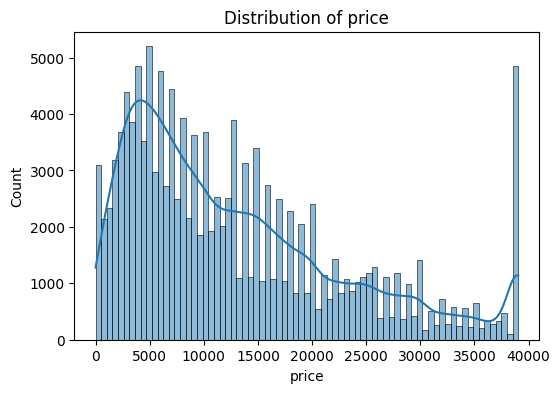

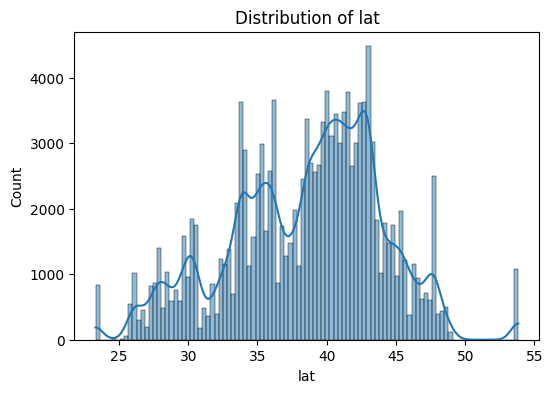

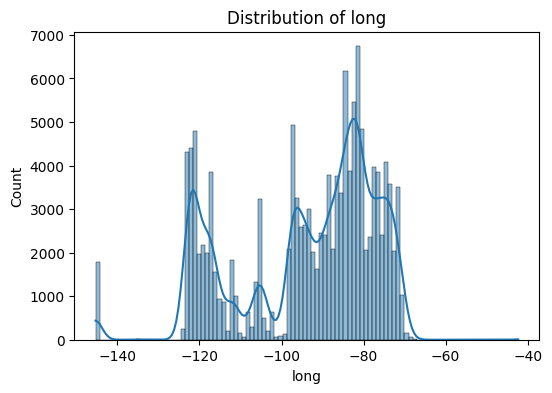

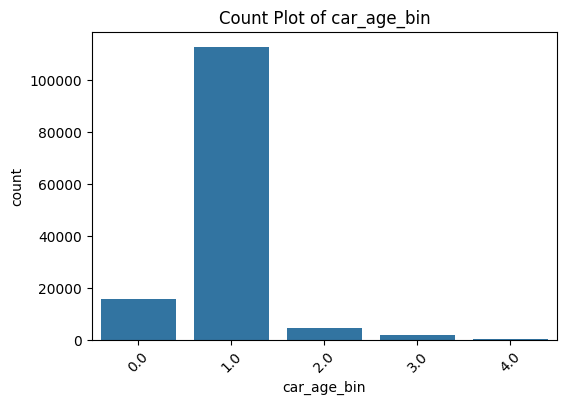

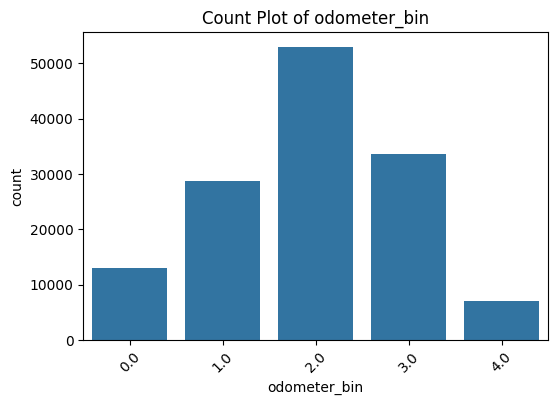

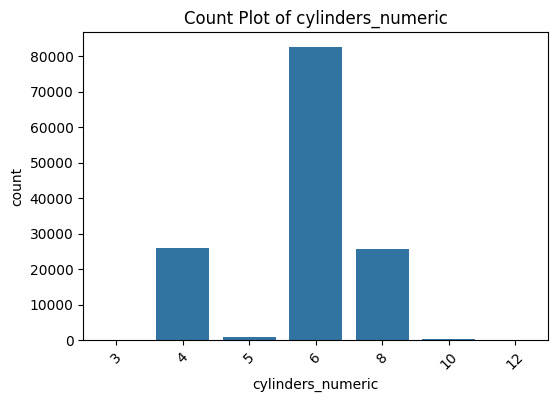

In [35]:
# Convert sample
sample_df = df.sample(fraction=0.3).toPandas()

import seaborn as sns
import matplotlib.pyplot as plt

continuous_cols = ['price', 'lat', 'long']

for col in continuous_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(sample_df[col], kde=True)
    plt.title(f"Distribution of {col}")
    
    plt.savefig(f"{base_dir}/distributions/{col}_hist.png")
    plt.show()

count_cols = ['car_age_bin', 'odometer_bin', 'cylinders_numeric']

for col in count_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=sample_df[col])
    plt.title(f"Count Plot of {col}")
    
    plt.xticks(rotation=45)
    plt.savefig(f"{base_dir}/distributions/{col}_count.png")
    plt.show()

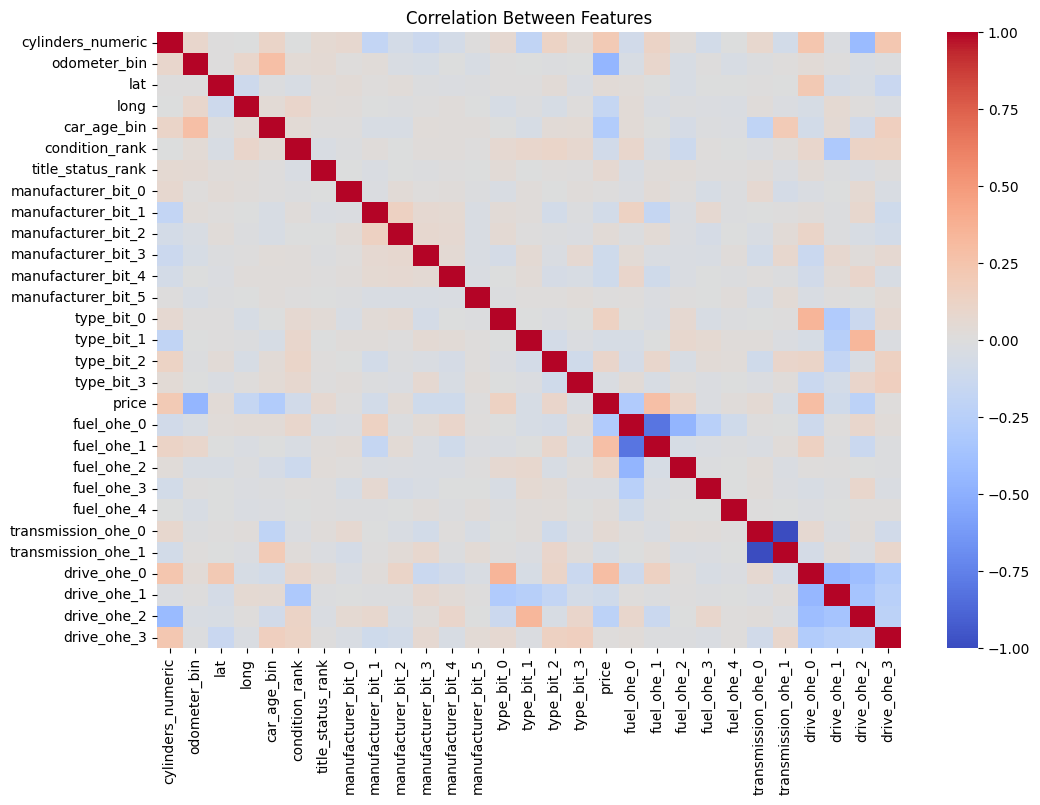

In [36]:
# Convert sample
sample_df = df.sample(fraction=0.3).toPandas()

import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix (all features)
corr_matrix = sample_df.corr()

# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title("Correlation Between Features")
plt.savefig(f"{base_dir}/correlation/feature_correlation_heatmap.png")
plt.show()

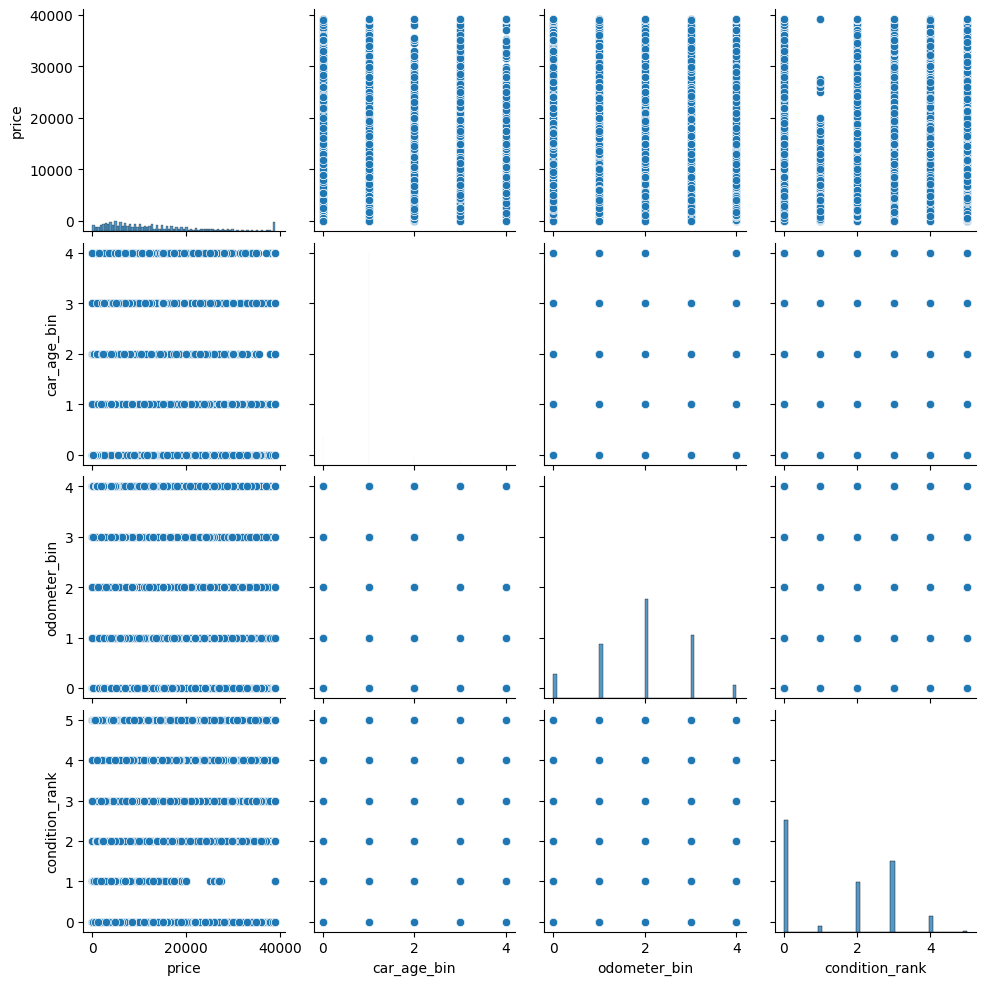

In [37]:
important_subset = sample_df[
    ['price', 'car_age_bin', 'odometer_bin', 'condition_rank']
]

# Create pairplot
pair_plot = sns.pairplot(important_subset)

# Save it
pair_plot.savefig(f"{base_dir}/correlation/pairplot_important_features.png")

# Show it
plt.show()

price                 1.000000
drive_ohe_0           0.293772
fuel_ohe_1            0.287709
cylinders_numeric     0.204962
type_bit_0            0.134952
fuel_ohe_2            0.104848
type_bit_2            0.096342
title_status_rank     0.064635
transmission_ohe_0    0.053061
manufacturer_bit_2    0.036991
lat                   0.034236
fuel_ohe_4            0.019818
drive_ohe_3           0.009995
manufacturer_bit_0    0.002638
manufacturer_bit_5    0.002587
fuel_ohe_3           -0.018380
type_bit_3           -0.024254
transmission_ohe_1   -0.053061
type_bit_1           -0.053124
manufacturer_bit_1   -0.079329
condition_rank       -0.091019
drive_ohe_1          -0.099914
manufacturer_bit_4   -0.102664
manufacturer_bit_3   -0.105157
long                 -0.165427
drive_ohe_2          -0.226176
car_age_bin          -0.286328
fuel_ohe_0           -0.293392
odometer_bin         -0.454506
Name: price, dtype: float64


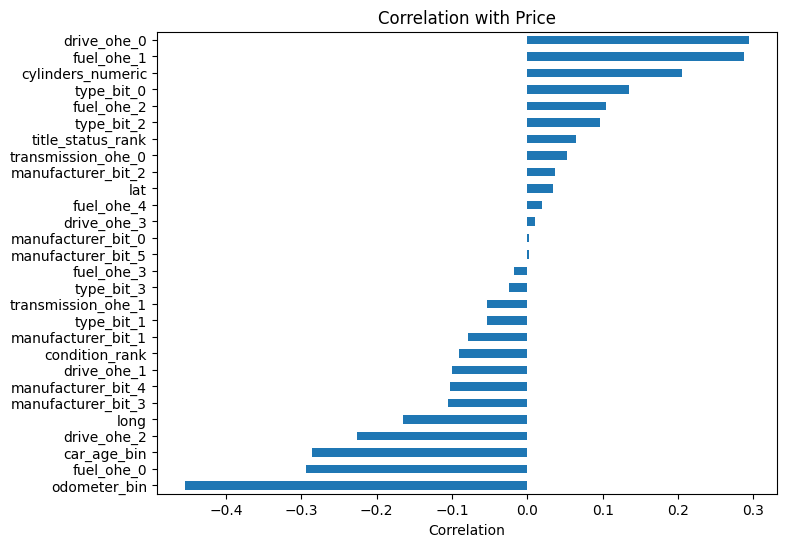

In [38]:
# Correlation with price
corr_price = corr_matrix['price'].sort_values(ascending=False)
print(corr_price)
plt.figure(figsize=(8,6))
corr_price.drop('price').sort_values().plot(kind='barh')
plt.title("Correlation with Price")
plt.xlabel("Correlation")
plt.savefig(f"{base_dir}/correlation/price_correlation.png")
plt.show()

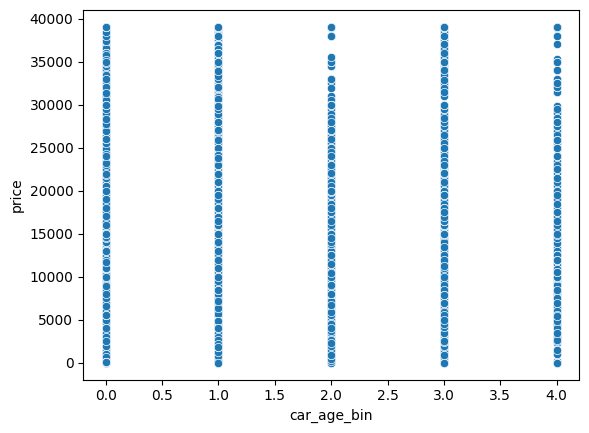

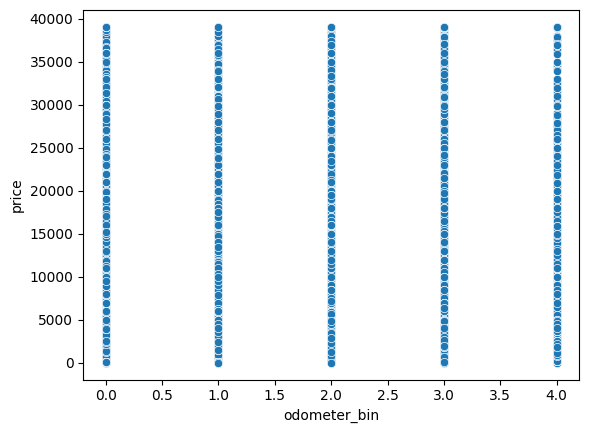

In [40]:
# Scatter for continuous-like
sns.scatterplot(x='car_age_bin', y='price', data=sample_df)
plt.savefig(f"{base_dir}/relationships/price_vs_age.png")
plt.show()

sns.scatterplot(x='odometer_bin', y='price', data=sample_df)
plt.savefig(f"{base_dir}/relationships/price_vs_odometer.png")
plt.show()

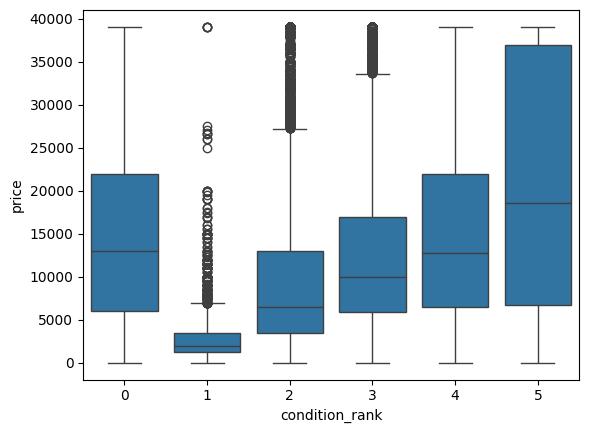

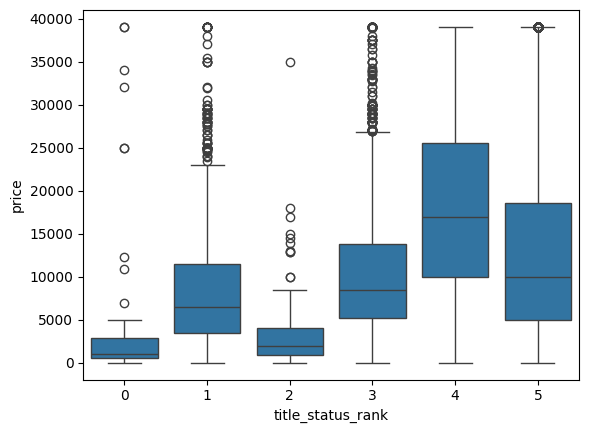

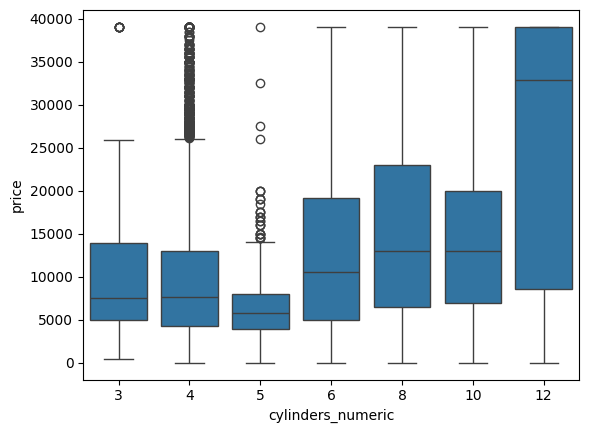

In [41]:
# Condition vs Price
sns.boxplot(x='condition_rank', y='price', data=sample_df)
plt.savefig(f"{base_dir}/relationships/condition_vs_price.png")
plt.show()

# Title Status vs Price
sns.boxplot(x='title_status_rank', y='price', data=sample_df)
plt.savefig(f"{base_dir}/relationships/title_vs_price.png")
plt.show()

# Cylinders vs Price 
sns.boxplot(x='cylinders_numeric', y='price', data=sample_df)
plt.savefig(f"{base_dir}/relationships/cylinders_vs_price.png")
plt.show()

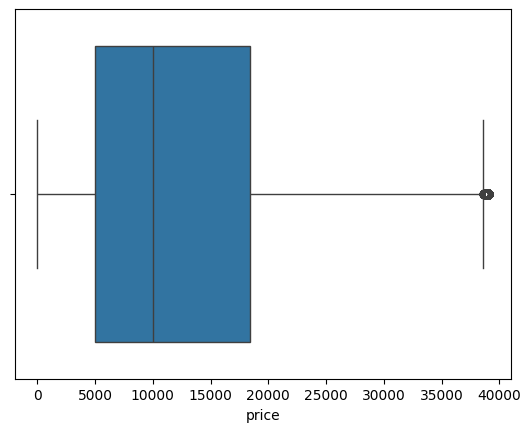

In [42]:
sns.boxplot(x=sample_df['price'])
plt.savefig(f"{base_dir}/outliers/price_outliers.png")
plt.show()